In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# kafka_data_baseline = pd.read_csv("data/kafka_metrics_fixed_10.csv")
# send_rate_baseline = pd.read_csv("data/rate_log_fixed_10.csv")
#
# sample_rates = pd.read_csv("data/sampling_rate_log_dynamic_10.csv", parse_dates=['timestamp'], date_parser=lambda x: pd.to_datetime(x, unit='s'))
# kafka_contrast = pd.read_csv("data/kafka_metrics_dynamic_10.csv")

kafka_data_baseline = pd.read_csv("data/kafka_metrics_aiops22_base.csv")
send_rate_baseline = pd.read_csv("data/rate_log_error-mid.csv")

sample_rates = pd.read_csv("data/sampling_rate_log_error-mid.csv", parse_dates=['timestamp'], dtype={'timestamp': 'int'}, date_parser=lambda x: pd.to_datetime(x, unit='s'))
kafka_contrast = pd.read_csv("data/kafka_metrics_error-mid.csv")

def trans_datetime(data):
    """
    转换时间字段为 datetime 类型，并计算相对时间（秒）
    :param data:
    :return:
    """
    data['timestamp'] = pd.to_datetime(data['timestamp']).dt.tz_localize('Asia/Shanghai')
    data['elapsed'] = (data['timestamp'] - data['timestamp'].min()).dt.total_seconds()
    return data

kafka_data_baseline = trans_datetime(kafka_data_baseline)
send_rate_baseline = trans_datetime(send_rate_baseline)
sample_rates = trans_datetime(sample_rates)
kafka_contrast = trans_datetime(kafka_contrast)

start_time = 0
end_time = min(kafka_data_baseline['elapsed'].max(),
                 kafka_contrast['elapsed'].max(),
                 send_rate_baseline['elapsed'].max(),
                 sample_rates['elapsed'].max())

C:\Users\12545\AppData\Local\Temp\ipykernel_75848\2507625536.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  sample_rates = pd.read_csv("data/sampling_rate_log_error-mid.csv", parse_dates=['timestamp'], dtype={'timestamp': 'int'}, date_parser=lambda x: pd.to_datetime(x, unit='s'))


In [30]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 全局字体与权重（适合 PPT）
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['figure.titlesize'] = 26

# 全局线宽和 marker 大小
plt.rcParams['lines.linewidth'] = 3        # 线条加粗
plt.rcParams['lines.markersize'] = 8      # marker 更大

# 更高分辨率（显示与保存基准）
plt.rcParams['figure.dpi'] = 150

In [31]:
def draw_lag_and_wait(kafka_data):
    """
    画出 Lag 和等待时间的双轴图
    :param kafka_data:
    :return:
    """
    fig, ax1 = plt.subplots(figsize=(14, 6))

    color_lag = 'tab:blue'
    color_wait = 'tab:orange'

    ax1.plot(kafka_data['elapsed'], kafka_data['lag'], label='Lag', color=color_lag)
    ax1.set_ylabel('Lag', color=color_lag)
    ax1.tick_params(axis='y', labelcolor=color_lag)
    ax1.set_xlim([start_time, end_time])

    ax2 = ax1.twinx()
    ax2.plot(kafka_data['elapsed'], kafka_data['wait_ms']/1000, label='等待时间 (s)', color=color_wait)
    ax2.set_ylabel('等待时间 (s)', color=color_wait)
    ax2.tick_params(axis='y', labelcolor=color_wait)
    ax2.set_xlim(ax1.get_xlim())

    ax1.set_xlabel('时间线')
    # 把两个轴的图例合并，在主坐标轴(ax1)内的右上角显示（框内）
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    handles = h1 + h2
    labels = l1 + l2
    leg = ax1.legend(handles, labels, loc='upper right', frameon=True)
    if leg is not None:
        leg.get_frame().set_linewidth(plt.rcParams.get('axes.linewidth', 1.0))
    plt.xticks(rotation=45)
    plt.title('Lag 与等待时间(s) 变化曲线')
    fig.tight_layout()
    plt.show()


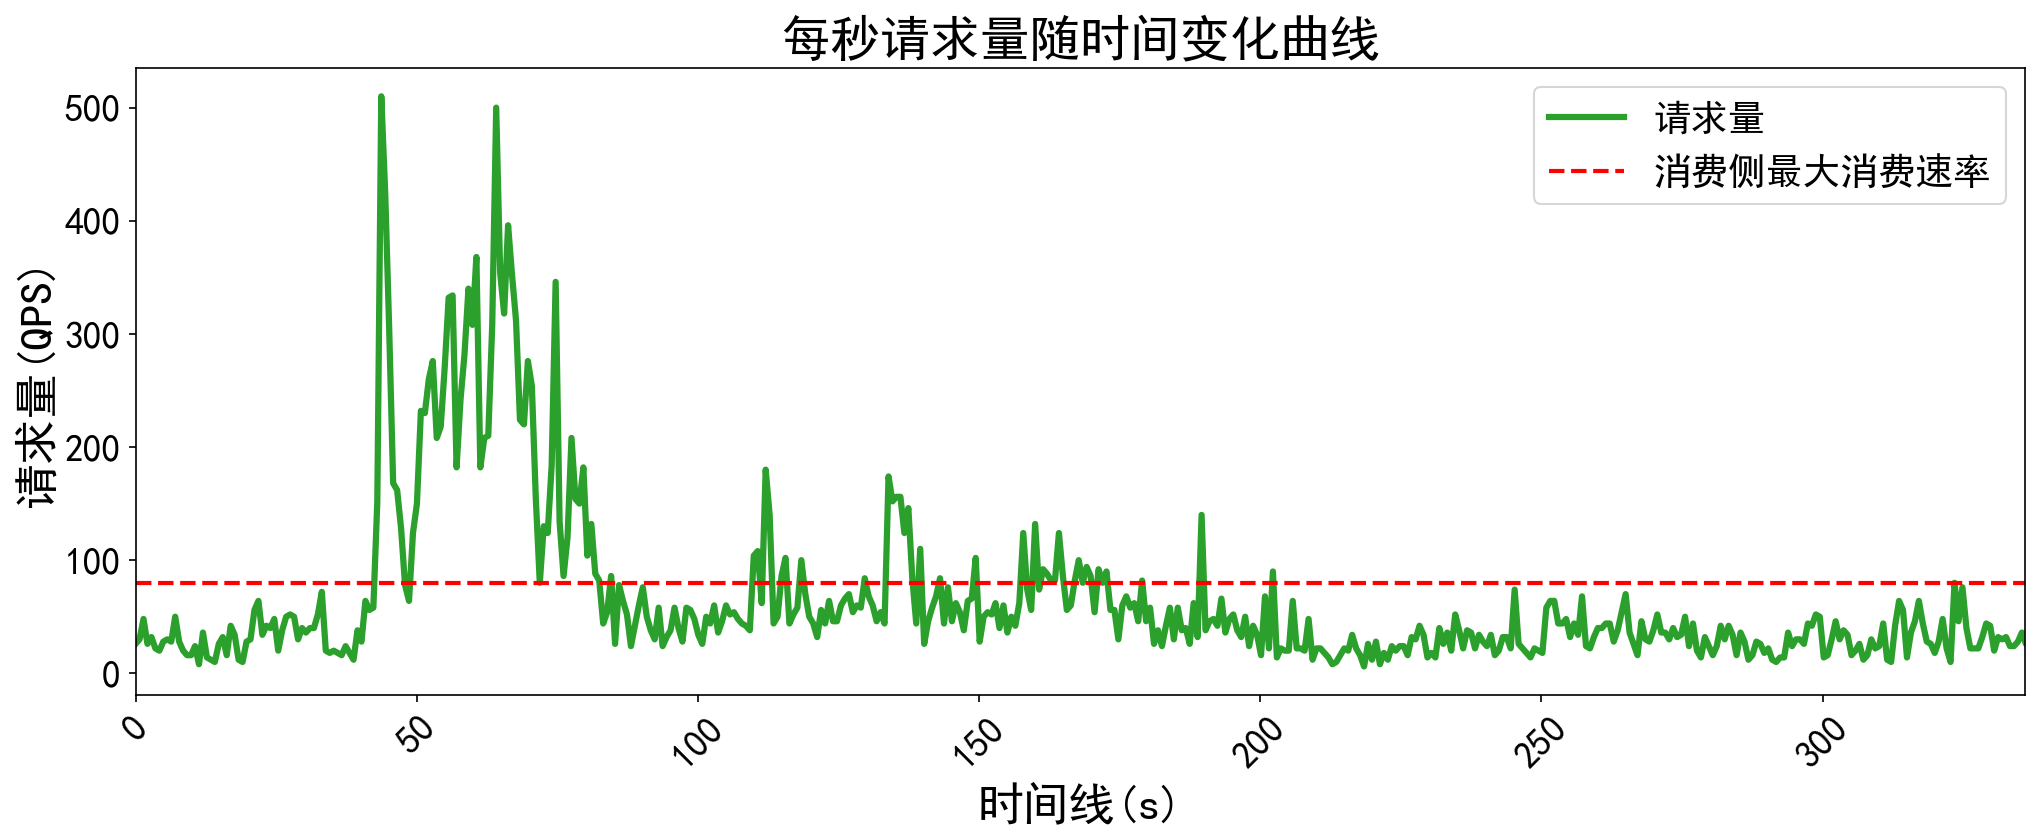

In [32]:
def draw_rate(send_rate):
    """
    画出 Rate 和参考线
    :param send_rate: DataFrame，包含 'elapsed' 和 'rate' 列
    :return:
    """
    plt.figure(figsize=(14, 6))
    plt.plot(send_rate['elapsed'], send_rate['rate'], label='请求量', color='tab:green')
    plt.axhline(y=80, color='red', linestyle='--', linewidth=2, label='消费侧最大消费速率')
    plt.xlim([start_time, end_time])
    plt.xlabel('时间线(s)')
    plt.ylabel('请求量(QPS)')
    plt.title('每秒请求量随时间变化曲线')
    plt.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

draw_rate(send_rate_baseline)


In [33]:

def draw_kafka_compare(baseline, contrast):
    """
    画出两个 Kafka 数据的 Lag 和等待时间对比图
    :param baseline:
    :param contrast:
    :return:
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(baseline['elapsed'], baseline['lag'], label='Baseline Lag', color='tab:blue')
    ax.plot(contrast['elapsed'], contrast['lag'], label='Contrast Lag', color='tab:orange')
    ax.set_xlabel('时间线')
    ax.set_ylabel('Lag')
    ax.set_title('Kafka Lag 对比图')
    ax.legend(loc='upper right')
    ax.set_xlim([start_time, end_time])
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(baseline['elapsed'], baseline['wait_ms']/1000, label='Baseline Wait', color='tab:blue')
    ax.plot(contrast['elapsed'], contrast['wait_ms']/1000, label='Contrast Wait', color='tab:orange')
    ax.set_xlabel('时间线 (s)')
    ax.set_ylabel('等待时间 (s)')
    ax.set_title('Kafka 等待时间对比图')
    ax.legend(loc='upper right')
    ax.set_xlim([start_time, end_time])
    plt.tight_layout()
    plt.show()



In [41]:
def draw_sampling_rate_changes(sampling_rate):
    """
    画出 actual_rate, current_sample_rate, delta
    :param sampling_rate:
    :return:
    """
    plt.figure(figsize=(14, 6))
    plt.plot(sampling_rate['elapsed'], sampling_rate['cumulative_actual_rate'], label='Actual Rate')
    plt.plot(sampling_rate['elapsed'], sampling_rate['actual_rate'], label='Current Sample Rate')
    plt.plot(sampling_rate['elapsed'], sampling_rate['current_sample_rate'], label='Current Base Sample Rate')
    # plt.plot(sampling_rate['timestamp'], sampling_rate['delta'], label='Delta')
    plt.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='目标采样率: 0.1')
    plt.xlim([start_time, end_time])
    plt.ylim([0, 1])
    plt.xlabel('时间线 (s)')
    plt.ylabel('采样率')
    plt.title('采样率相关属性随时间变化曲线')
    plt.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

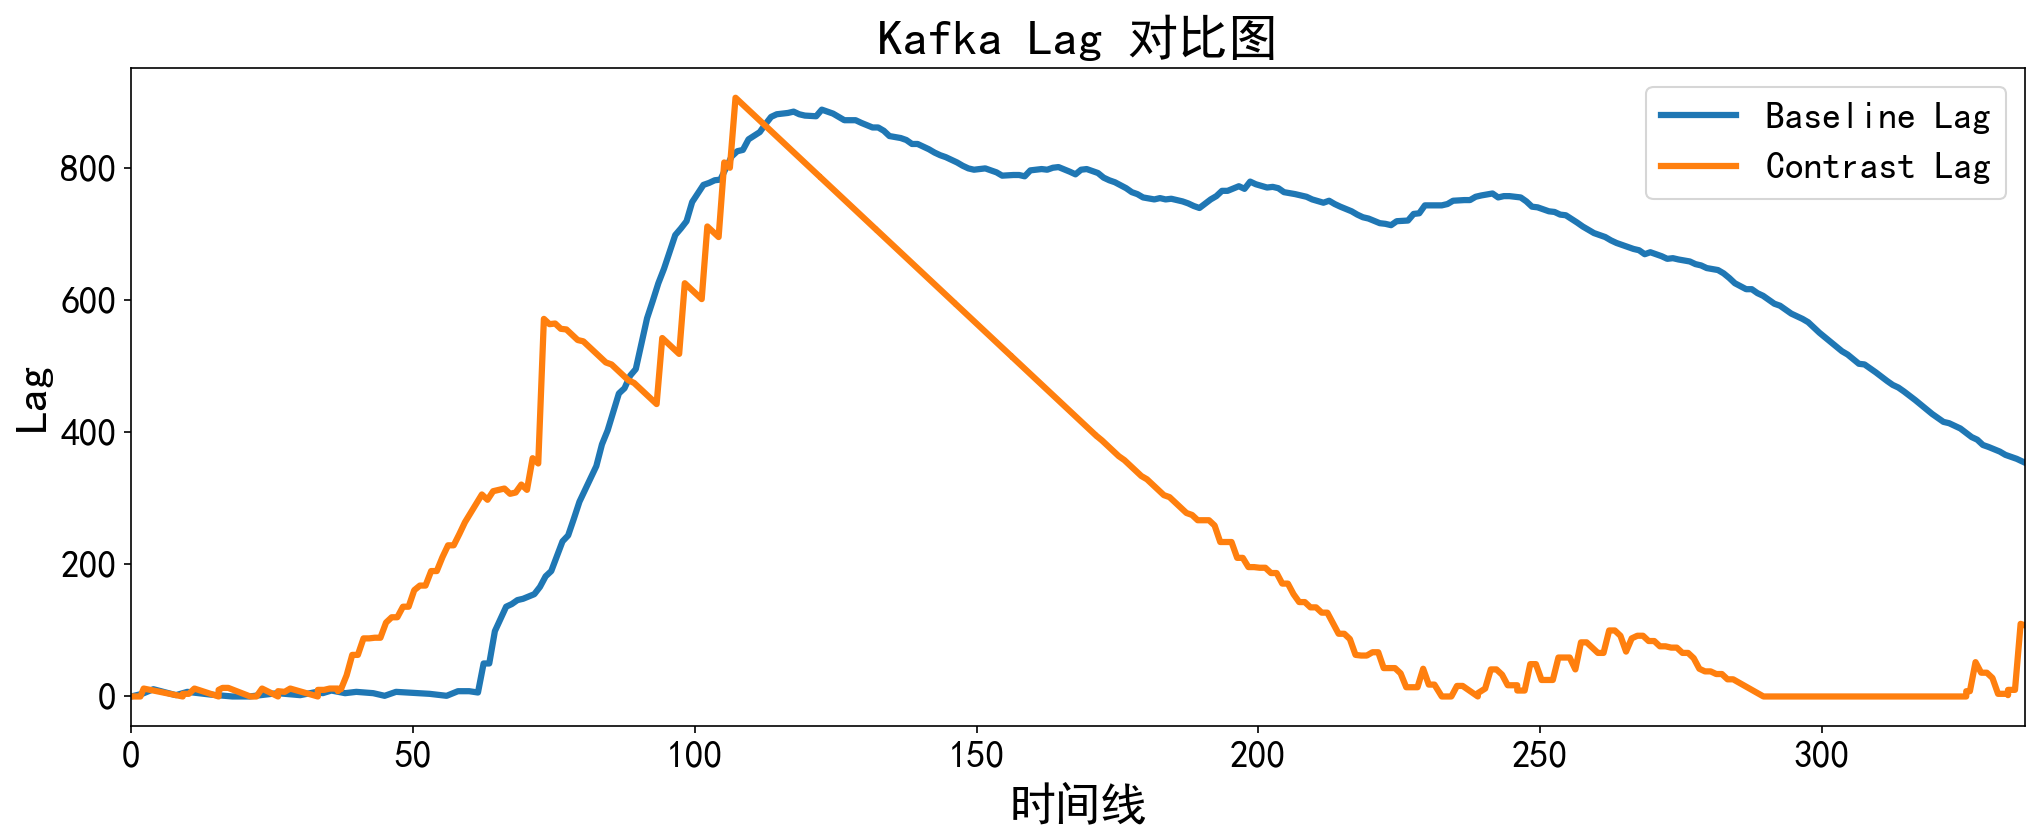

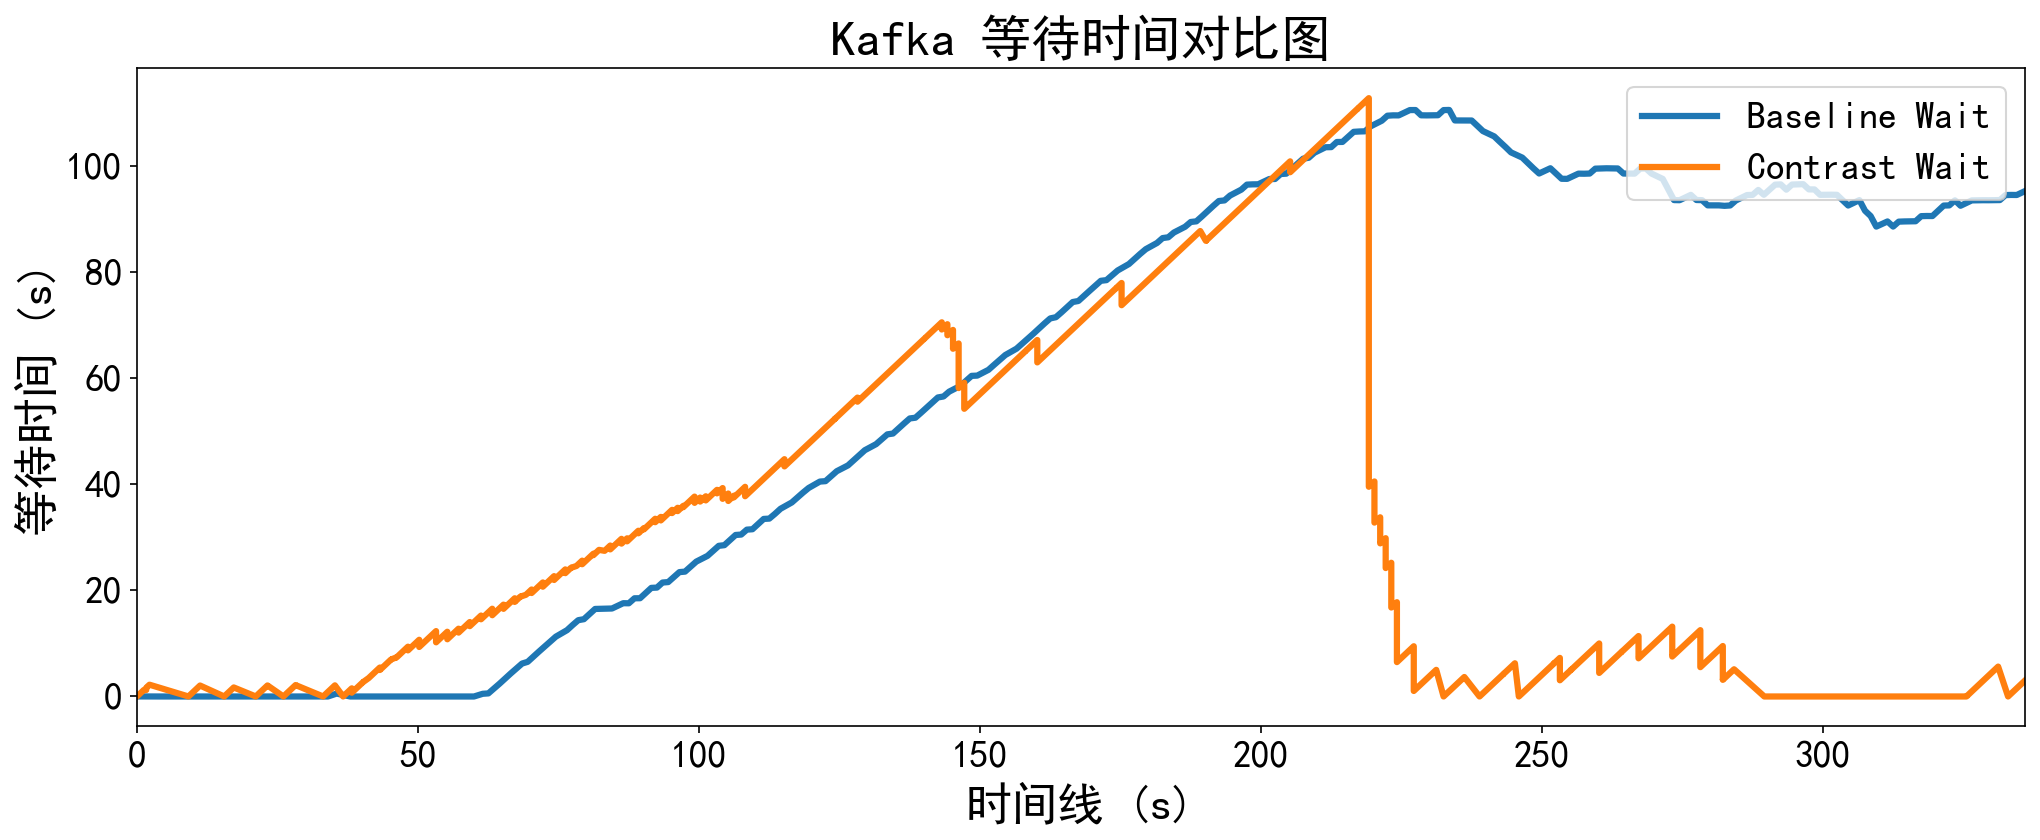

In [35]:
draw_kafka_compare(kafka_data_baseline[::10], kafka_contrast)

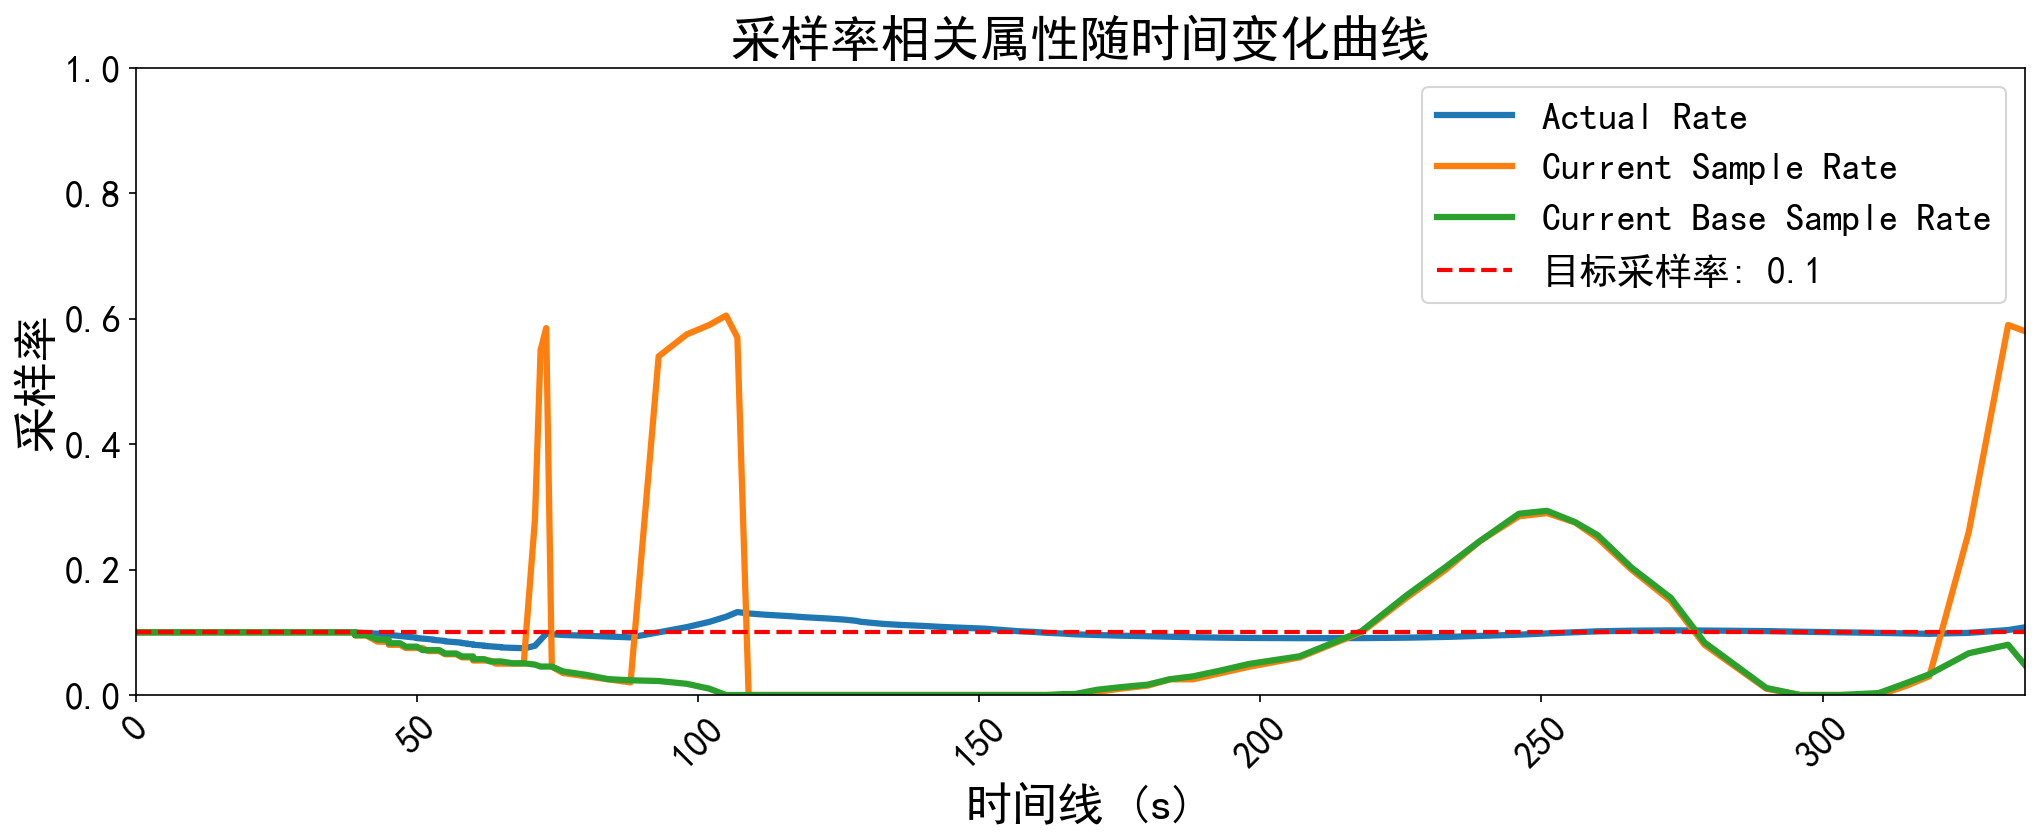

In [42]:
draw_sampling_rate_changes(sample_rates)

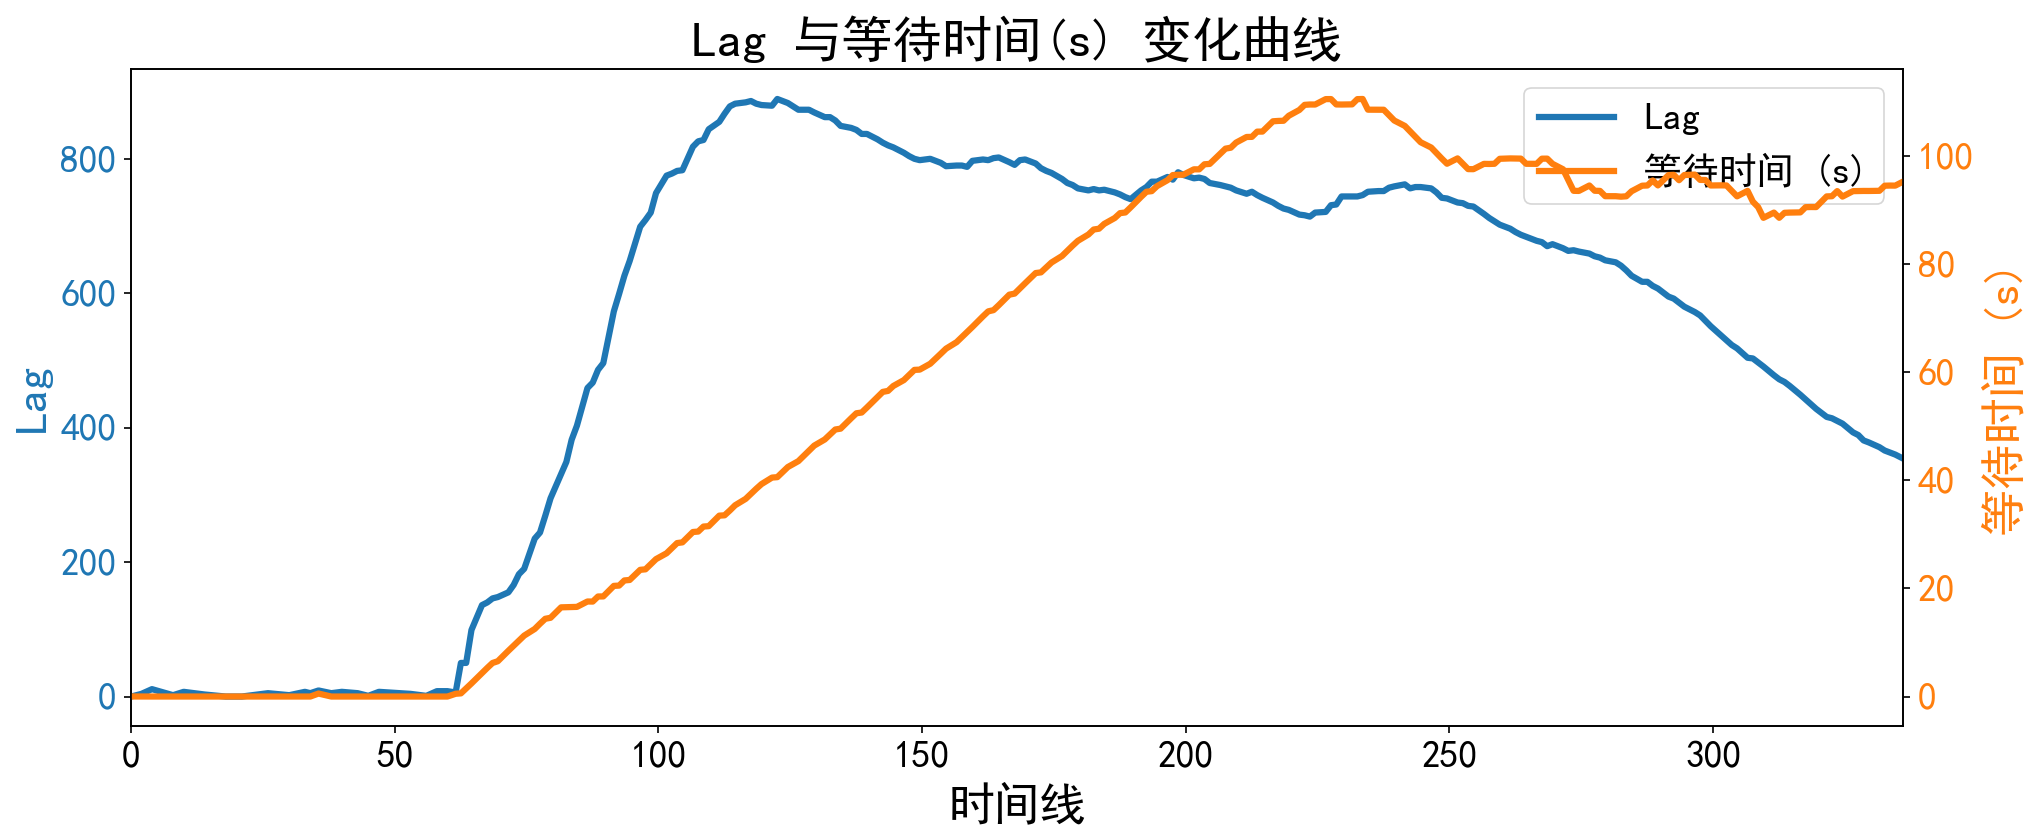

In [37]:
draw_lag_and_wait(kafka_data_baseline[::10])

In [38]:
kafka_data_baseline['wait_ms'].max(), kafka_contrast['wait_ms'].max()


(111527, 112789)

In [39]:
kafka_data_baseline['lag'].max(), kafka_contrast['lag'].max()


(889, 907)

In [40]:
sample_rates

,timestamp,actual_rate,cumulative_actual_rate,current_sample_rate,encode_cost_ms,sample_cost_ms,abnormal_count,trace_count,sample_count,elapsed
0,2025-11-25 11:53:22+08:00,0.100,0.100000,0.100000,0.00,6.00,0,200,1,0.0
1,2025-11-25 11:53:31+08:00,0.100,0.100000,0.100000,0.00,6.50,0,400,2,9.0
2,2025-11-25 11:53:38+08:00,0.100,0.100000,0.100000,0.01,9.00,0,600,3,16.0
3,2025-11-25 11:53:43+08:00,0.100,0.100000,0.100000,0.03,10.50,0,800,4,21.0
4,2025-11-25 11:53:48+08:00,0.100,0.100000,0.100000,0.04,12.00,0,1000,5,26.0
...,...,...,...,...,...,...,...,...,...,...
105,2025-11-25 11:58:37+08:00,0.015,0.098208,0.019458,0.32,8.93,0,21200,106,315.0
106,2025-11-25 11:58:41+08:00,0.030,0.097570,0.033098,0.32,8.85,0,21400,107,319.0
107,2025-11-25 11:58:48+08:00,0.260,0.099074,0.066610,0.33,8.91,52,21600,108,326.0
108,2025-11-25 11:58:55+08:00,0.590,0.103578,0.080171,0.33,9.27,118,21800,109,333.0
